In [3]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Read the Dataset
car = pd.read_csv(r"C:\Users\Jagrati\Downloads\car+evaluation\car.data",header=None)
car.head()

,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [5]:
#Rename Columns
car.columns = [
    "buying",
    "maint",
    "doors",
    "persons",
    "lug_boot",
    "safety",
    "class"
]

car.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [6]:
#Check Dataset Shape
car.shape

(1728, 7)

In [7]:
#Dataset Information
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [8]:
#Statistical Summary
car.describe(include="all")

,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [9]:
#Check Missing Values
car.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [10]:
#Check Duplicate Values
duplicates = car.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [11]:
#If duplicates exist

if duplicates > 0:
    car = car.drop_duplicates()

In [12]:
#Check Unique Values
for col in car.columns:
    print(col)
    print(car[col].unique())
    print("-------------------")

buying
['vhigh' 'high' 'med' 'low']
-------------------
maint
['vhigh' 'high' 'med' 'low']
-------------------
doors
['2' '3' '4' '5more']
-------------------
persons
['2' '4' 'more']
-------------------
lug_boot
['small' 'med' 'big']
-------------------
safety
['low' 'med' 'high']
-------------------
class
['unacc' 'acc' 'vgood' 'good']
-------------------


In [13]:
#Class Distribution
car["class"].value_counts()

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

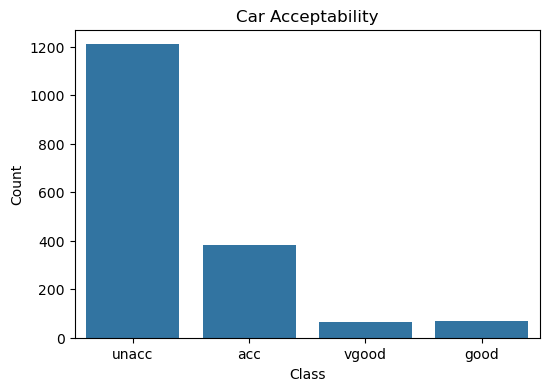

In [14]:
#Plot Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="class", data=car)
plt.title("Car Acceptability")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

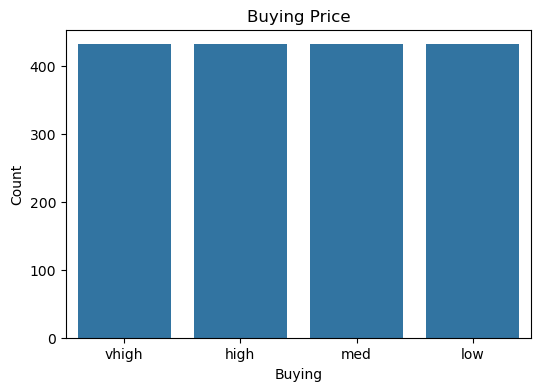

In [15]:
#Buying Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="buying", data=car)
plt.title("Buying Price")
plt.xlabel("Buying")
plt.ylabel("Count")
plt.show()

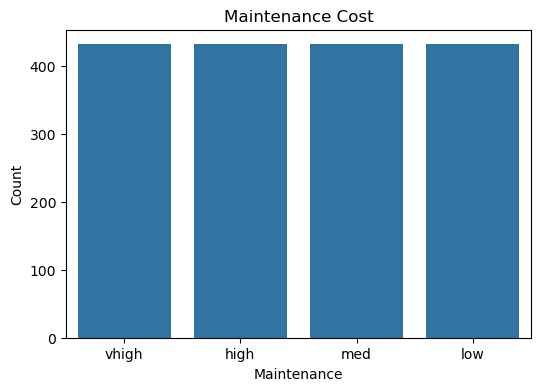

In [16]:
#Maintenance Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="maint", data=car)
plt.title("Maintenance Cost")
plt.xlabel("Maintenance")
plt.ylabel("Count")
plt.show()

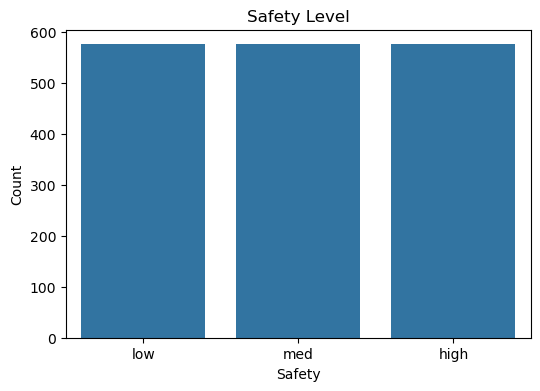

In [17]:
#Safety Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="safety", data=car)
plt.title("Safety Level")
plt.xlabel("Safety")
plt.ylabel("Count")
plt.show()

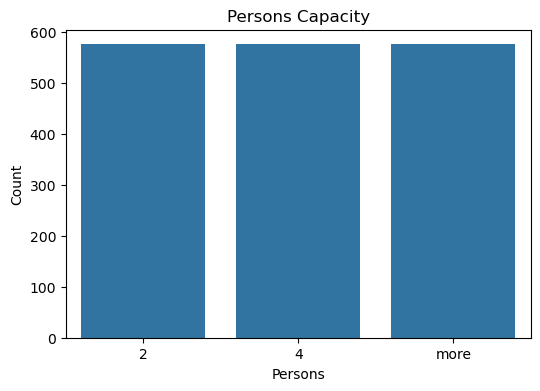

In [18]:
#Persons Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="persons", data=car)
plt.title("Persons Capacity")
plt.xlabel("Persons")
plt.ylabel("Count")
plt.show()

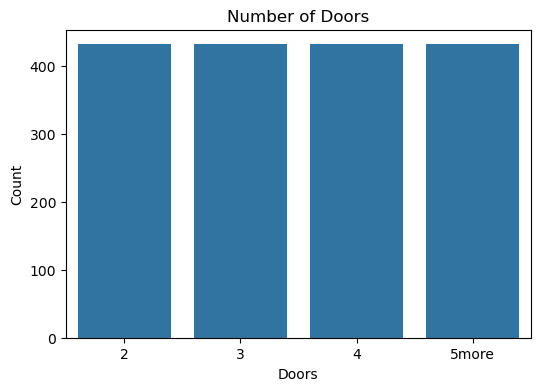

In [19]:
#Doors Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="doors", data=car)
plt.title("Number of Doors")
plt.xlabel("Doors")
plt.ylabel("Count")
plt.show()

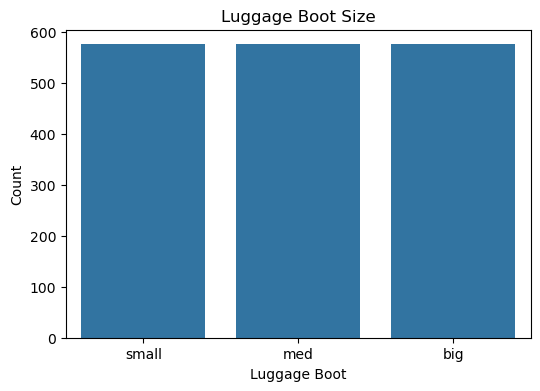

In [20]:
#Luggage Boot Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="lug_boot", data=car)
plt.title("Luggage Boot Size")
plt.xlabel("Luggage Boot")
plt.ylabel("Count")
plt.show()

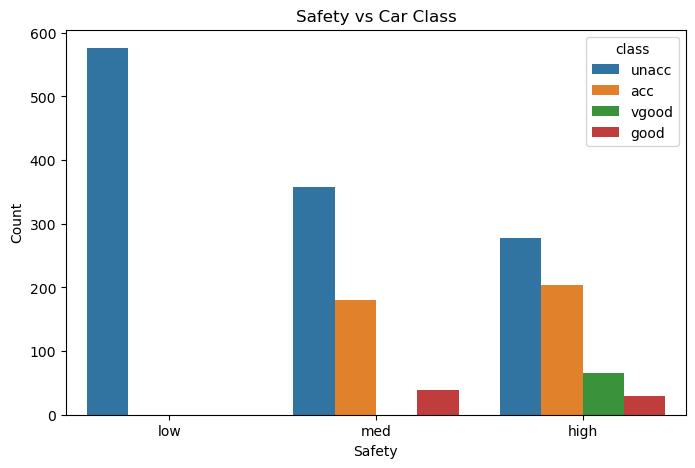

In [21]:
#Safety vs Class
plt.figure(figsize=(8,5))
sns.countplot(x="safety", hue="class", data=car)
plt.title("Safety vs Car Class")
plt.xlabel("Safety")
plt.ylabel("Count")
plt.show()

In [22]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in car.columns:
    car[col] = le.fit_transform(car[col])

car.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


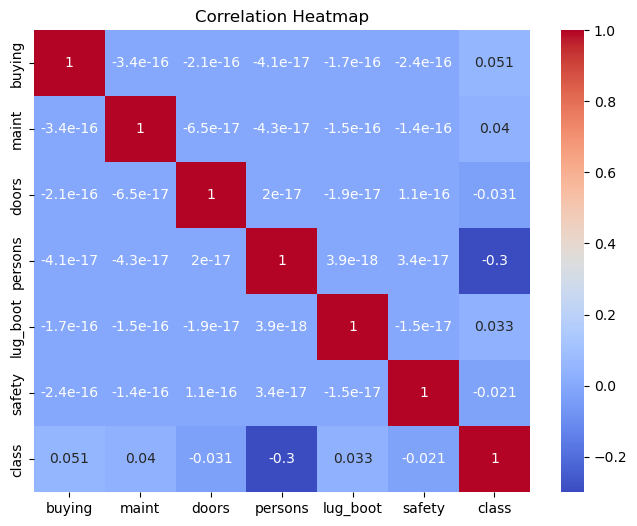

In [23]:
#Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(car.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [24]:
#Define Features and Target
X = car.drop("class", axis=1)

y = car["class"]

In [25]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
#Train Decision Tree Model
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [27]:
#Prediction
y_pred = model.predict(X_test)

In [28]:
#Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9855491329479769


In [29]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        77
           1       0.93      1.00      0.97        14
           2       1.00      0.99      1.00       242
           3       1.00      0.85      0.92        13

    accuracy                           0.99       346
   macro avg       0.97      0.96      0.96       346
weighted avg       0.99      0.99      0.99       346



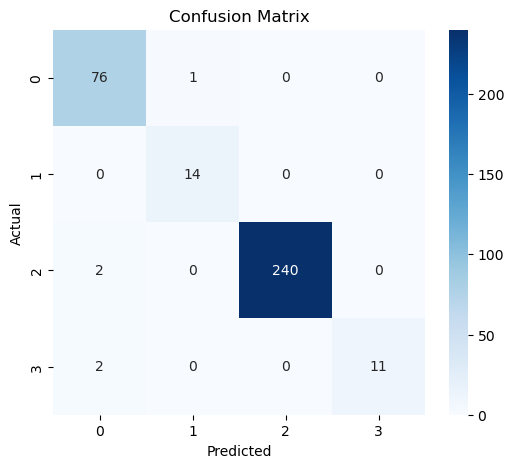

In [30]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

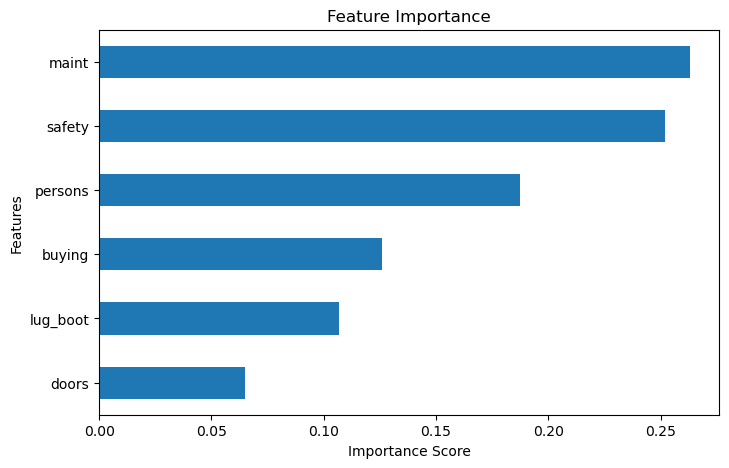

In [31]:
#Feature Importance
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh", figsize=(8,5))

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()